# Klasifikacija žanra filma na osnovu teksta

| # | Model | Poreklo |
|---|-------|---------|
| 1 | GloVe (prosek) + MLP 300→50→13 | **replikacija rada** |
| 2 | TF-IDF + Logistička regresija | naše |
| 3 | MiniLM embedinzi + LogReg | naše |

## 1. Priprema

In [ ]:
import sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from helpers import (load_split, clean_plot, GENRES, evaluate, per_genre_ap,
                    tune_thresholds, results_table, PAPER_RESULTS,
                    load_glove, glove_encode)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

MODELS = ROOT / "models"
MODELS.mkdir(exist_ok=True)

In [2]:
train = load_split("train")
val   = load_split("val")
test  = load_split("test")

X_train = clean_plot(train["plot"])
X_val = clean_plot(val["plot"])
X_test = clean_plot(test["plot"])

y_train, y_val, y_test = train[GENRES].values, val[GENRES].values, test[GENRES].values

print(f"train {len(train):5d}   val {len(val):5d}   test {len(test):5d}")

train  3454   val   491   test   989


## 2. Kratka analiza podataka

Koliko je skup neizbalansiran, koliko žanrova ima film, kolika je dužina tekstova.

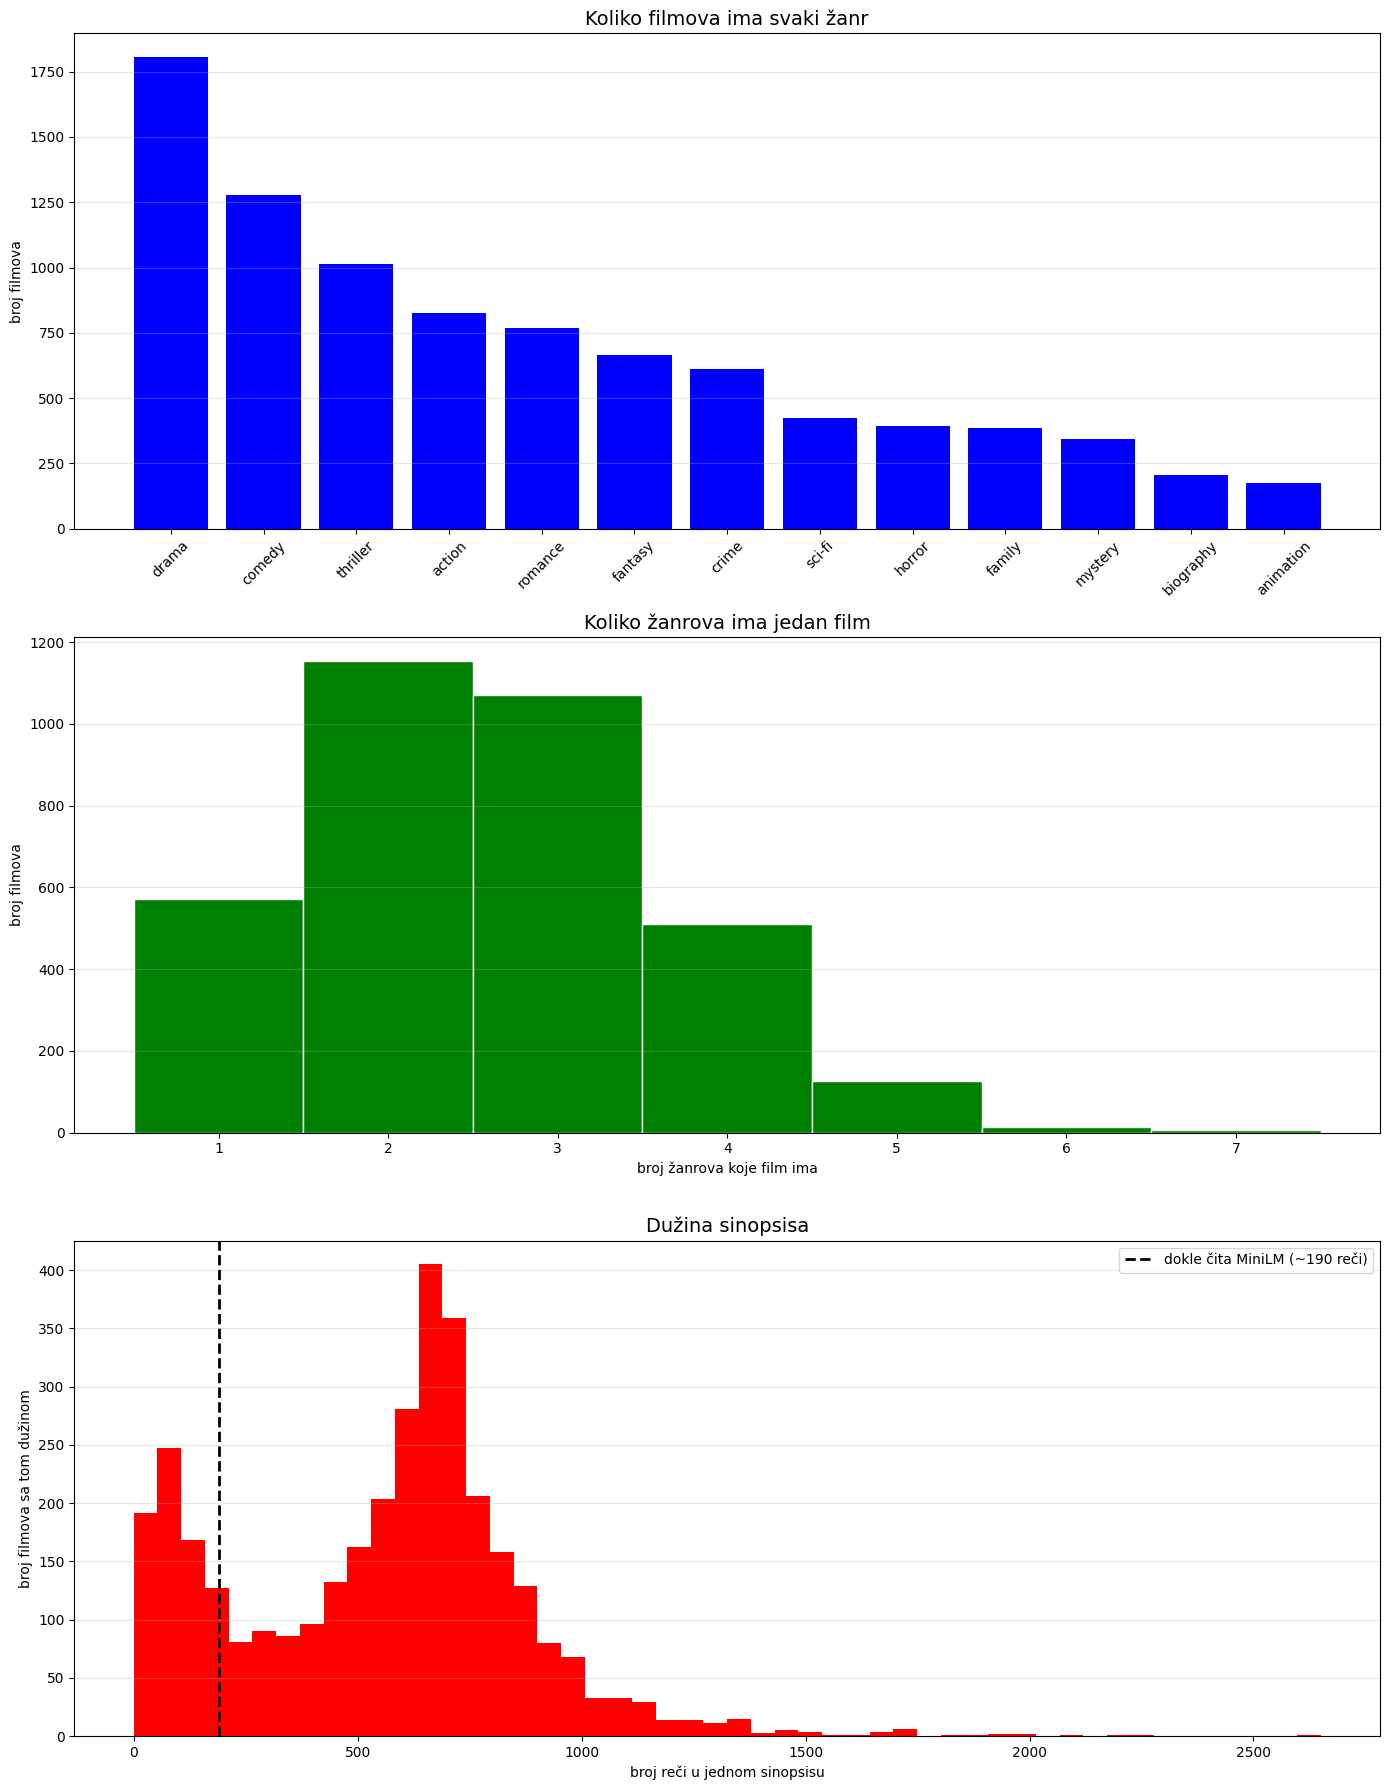

prosečno žanrova po filmu : 2.58
medijana dužine sinopsisa : 613 reči
najčešći/najređi žanr      : 1806/175 = 10.3x razlike
kod 80% filmova MiniLM preskoči većinu teksta


In [3]:
fig, ax = plt.subplots(3, 1, figsize=(14, 18))

# (a) koliko filmova ima svaki zanr
counts = train[GENRES].sum().sort_values(ascending=False)
ax[0].bar(counts.index, counts.values, color="blue")
ax[0].set_title("Koliko filmova ima svaki žanr", fontsize=14)
ax[0].set_ylabel("broj filmova")
ax[0].tick_params(axis="x", rotation=45)
ax[0].grid(axis="y", alpha=0.3)

# (b) koliko zanrova ima jedan film
per_movie = train[GENRES].sum(axis=1)
ax[1].hist(per_movie, bins=range(1, per_movie.max() + 2), align="left",
           color="green", edgecolor="white")
ax[1].set_title("Koliko žanrova ima jedan film", fontsize=14)
ax[1].set_xlabel("broj žanrova koje film ima")
ax[1].set_ylabel("broj filmova")
ax[1].grid(axis="y", alpha=0.3)

# (c) duzina sinopsisa
# x = koliko reci ima sinopsis, y = koliko filmova ima sinopsis te duzine
lens = train["plot"].fillna("").str.split().str.len()
ax[2].hist(lens, bins=50, color="red")
ax[2].axvline(190, color="black", ls="--", lw=2,
              label="dokle čita MiniLM (~190 reči)")
ax[2].set_title("Dužina sinopsisa", fontsize=14)
ax[2].set_xlabel("broj reči u jednom sinopsisu")
ax[2].set_ylabel("broj filmova sa tom dužinom")
ax[2].legend()
ax[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"prosečno žanrova po filmu : {per_movie.mean():.2f}")
print(f"medijana dužine sinopsisa : {int(lens.median())} reči")
print(f"najčešći/najređi žanr      : {counts.max()}/{counts.min()} = {counts.max()/counts.min():.1f}x razlike")
print(f"kod {(lens > 190).mean()*100:.0f}% filmova MiniLM preskoči većinu teksta")

**Zapažanja:**

- Skup je jako neizbalansiran — `drama` ima ~10x više primera od `animation`.
  Zato svuda koristimo težine klasa, a kao glavnu metriku gledamo **macro** AP
  koja svaki žanr broji podjednako.
- Film ima u proseku 2.6 žanra — potvrda da je zadatak multi-label.
- **Medijana sinopsisa je ~600 reči.** Ovaj broj će kasnije objasniti zašto
  MiniLM podbacuje.

---
# Deo I — Replikacija modela iz rada

Iz rada (odeljak 4, str. 3):

> *"The plot summaries were truncated to max 3000 word length, then transformed
> into a 1x300 vector using the GloVe 42B CommonCrawl embedding. Outputs were
> produced using a 300x50, and 50x13 fully-connected layers."*

Plus, iz istog odeljka: BCE sa težinama pozitivnih primera, sigmoid na izlazu,
Adam optimizator, batch 64, early stopping po validacionoj grešci.

**Jedno odstupanje:** rad koristi GloVe **42B CommonCrawl** (5 GB). Mi koristimo
**6B Wikipedia+Gigaword** (1 GB) jer je 5x manji, a razlika u kvalitetu je mala.
Ovo je zabeleženo u zaključcima.

### 4.1 GloVe embedinzi

In [4]:
t0 = time.time()
vocab, emb = load_glove()          # data/glove/glove.6B.300d.txt
print(f"GloVe: {len(vocab)} reči x {emb.shape[1]} dimenzija  ({time.time()-t0:.0f}s)")

GloVe: 400001 reči x 300 dimenzija  (33s)


Svaka reč je tačka u prostoru od 300 dimenzija, gde su slične reči blizu.
Rad ceo sinopsis svodi na **jedan** vektor tako što izračuna prosek vektora svih reči.

To je snažno ograničenje: računanje proseka briše redosled reči, a retke reči
(*zombie*, *spaceship*) se utope među stotinama čestih. Baš su te retke reči
one koje odaju žanr.

In [5]:
t0 = time.time()
X_train_glove = glove_encode(X_train, vocab, emb)    # skraćivanje na 3000 reči + prosek
X_val_glove = glove_encode(X_val, vocab, emb)
X_test_glove = glove_encode(X_test, vocab, emb)
print(f"izračunato za {time.time()-t0:.0f}s  |  oblik: {X_train_glove.shape}")
print(f"\ncelih {int(train['plot'].fillna('').str.split().str.len().median())} reči teksta -> svega 300 brojeva")

izračunato za 3s  |  oblik: (3454, 300)



celih 613 reči teksta -> svega 300 brojeva


### 4.2 Mreža 300 → 50 → 13

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(RANDOM_STATE)


class TextGenreModel(nn.Module):
    """Mreza iz rada: dva potpuno povezana sloja, 300 -> 50 -> 13."""

    def __init__(self, input_size=300, hidden_size=50, output_size=13):
        super(TextGenreModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.fc2(x)
        return x


pos_weight = torch.tensor((len(y_train) - y_train.sum(0)) / y_train.sum(0),
                          dtype=torch.float32)

print("tezine po zanru:")
print(pd.Series(pos_weight.numpy().round(1), index=GENRES).to_string())

tezine po zanru:
action        3.200000
animation    18.700001
biography    15.700000
comedy        1.700000
crime         4.700000
drama         0.900000
family        8.000000
fantasy       4.200000
horror        7.700000
mystery       9.000000
romance       3.500000
sci-fi        7.100000
thriller      2.400000


Bez ovih težina model bi naučio da uvek predviđa `drama` i time bio "u pravu"
najveći deo vremena. Rad to eksplicitno navodi kao problem na koji su naišli.

In [7]:
def train_model(X_train_glove, y_train, X_val_glove, y_val,
                epochs=200, patience=20, batch_size=64):
    """Trenira mrezu sa ranim prekidom po validacionoj gresci (kao u radu)."""
    model = TextGenreModel()
    optimizer = optim.Adam(model.parameters())
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    train_dataset = TensorDataset(torch.tensor(X_train_glove),
                                  torch.tensor(y_train, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    X_val_tensor = torch.tensor(X_val_glove)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

    history = {"train_loss": [], "val_loss": []}
    best_loss, epochs_without_improvement, best_state = float("inf"), 0, None

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for inputs, labels in train_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(inputs)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_tensor), y_val_tensor).item()

        history["train_loss"].append(total_loss / len(train_dataset))
        history["val_loss"].append(val_loss)

        if epoch % 10 == 0:
            print(f"  epoha {epoch:3d}   trening {history['train_loss'][-1]:.4f}   "
                  f"validacija {val_loss:.4f}")

        if val_loss < best_loss - 1e-4:
            best_loss, epochs_without_improvement = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"rani prekid na epohi {epoch} "
                      f"(najbolja validaciona greska: {best_loss:.4f})")
                break

    model.load_state_dict(best_state)
    model.eval()
    return model, history


start = time.time()
paper_model, history = train_model(X_train_glove, y_train, X_val_glove, y_val)
print(f"trenirano za {time.time() - start:.0f}s")

  epoha   0   trening 1.1071   validacija 1.0792


  epoha  10   trening 0.7909   validacija 0.7885


  epoha  20   trening 0.7084   validacija 0.7242


  epoha  30   trening 0.6721   validacija 0.7040


  epoha  40   trening 0.6458   validacija 0.6943


...

  epoha  70   trening 0.5969   validacija 0.6833


  epoha  80   trening 0.5846   validacija 0.6813


  epoha  90   trening 0.5721   validacija 0.6859


  epoha 100   trening 0.5627   validacija 0.6823


rani prekid na epohi 107 (najbolja validaciona greska: 0.6787)
trenirano za 31s


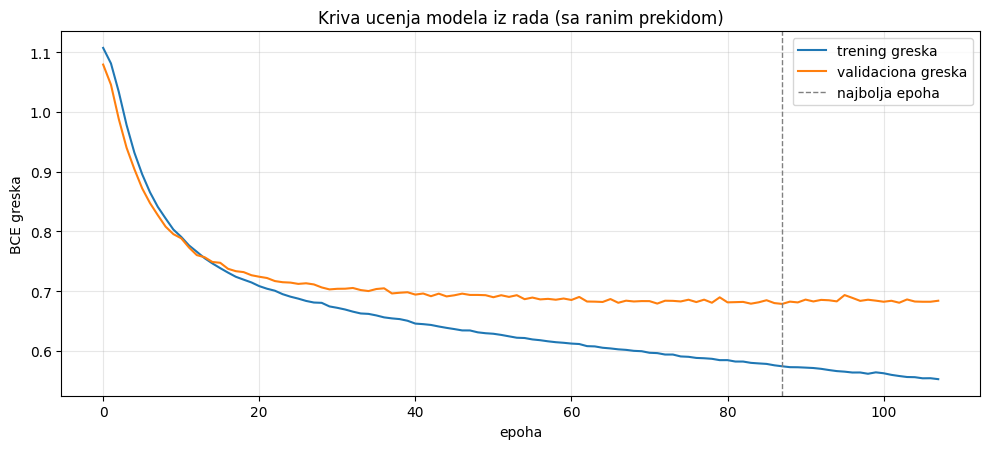

In [8]:
# Kriva ucenja -- odgovara Fig 4 iz rada
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(history["train_loss"], label="trening greska")
ax.plot(history["val_loss"], label="validaciona greska")
ax.axvline(int(np.argmin(history["val_loss"])), ls="--", c="gray", lw=1,
           label="najbolja epoha")
ax.set_xlabel("epoha")
ax.set_ylabel("BCE greska")
ax.set_title("Kriva ucenja modela iz rada (sa ranim prekidom)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
def predict_probabilities(model, features):
    """Propusti podatke kroz mrezu i vrati verovatnoce (sigmoid nad logitima)."""
    with torch.no_grad():
        return torch.sigmoid(model(torch.tensor(features))).numpy()


score_glove_va = predict_probabilities(paper_model, X_val_glove)
score_glove_te = predict_probabilities(paper_model, X_test_glove)

thresholds_glove = tune_thresholds(y_val, score_glove_va)
replication = evaluate(y_test, score_glove_te, thresholds_glove,
                       "GloVe + MLP (replikacija)")

comparison_with_paper = pd.DataFrame([
    {"izvor": "nasa replikacija",
     **{k: replication[k] for k in ["AP_micro", "AP_macro", "AP_samples"]}},
    {"izvor": "rad (LeBaron)",
     "AP_micro": 0.631661, "AP_macro": 0.619510, "AP_samples": 0.749681},
]).set_index("izvor").round(4)

print("=== REPLIKACIJA vs RAD (test skup) ===")
print(comparison_with_paper.to_string())
print("\nrazlika:", (comparison_with_paper.iloc[0]
                     - comparison_with_paper.iloc[1]).round(4).to_dict())

=== REPLIKACIJA vs RAD (test skup) ===
                  AP_micro  AP_macro  AP_samples
izvor                                           
nasa replikacija    0.6564    0.6619      0.7614
rad (LeBaron)       0.6317    0.6195      0.7497

razlika: {'AP_micro': 0.0247, 'AP_macro': 0.0424, 'AP_samples': 0.0117}


**Replikacija je uspela.** Brojevi su vrlo blizu objavljenih, uz malo odstupanje
naviše — najverovatnije zato što smo popravili pokvareno kodiranje u trećini
sinopsisa i što biramo pragove po žanru.

Time je potvrđeno da naš lanac obrade radi ispravno. Sve što od sada bude bolje
od ovog broja je zasluga **metode**, a ne razlike u podacima.

---
# Deo II — Naši modeli

Polazna hipoteza: glavno ograničenje modela iz rada je **računanje proseka**.
Sinopsis od 600 reči svede se na 300 brojeva, čime nestaje informacija o tome
koje su se tačno reči pojavile.

TF-IDF radi suprotno — zadržava desetine hiljada pojedinačnih reči i daje
najveću težinu onima koje su retke, a upravo one odaju žanr.

## 5. TF-IDF reprezentacija

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=50_000,    # gornja granica rečnika
    ngram_range=(1, 2),     # reči + parovi reči ("serial killer")
    min_df=2,               # reč mora da se javi bar u 2 dokumenta
    sublinear_tf=True,      # log(tf) -- prigušuje česta ponavljanja
    stop_words="english",
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF matrica:", X_train_tfidf.shape)
print(f"-> {X_train_tfidf.shape[1]} crta naspram 300 kod GloVe pristupa")

TF-IDF matrica: (3454, 50000)
-> 50000 crta naspram 300 kod GloVe pristupa


## 6. Model 2 — TF-IDF + Logistička regresija

`OneVsRestClassifier` trenira 13 nezavisnih binarnih klasifikatora, po jedan za
svaki žanr. `class_weight="balanced"` igra istu ulogu kao `pos_weight` u radu.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

t0 = time.time()
logreg = OneVsRestClassifier(
    LogisticRegression(max_iter=2000, C=4, class_weight="balanced",
                       random_state=RANDOM_STATE),
    n_jobs=-1,
).fit(X_train_tfidf, y_train)

score_logreg_va = logreg.predict_proba(X_val_tfidf)
score_logreg_te = logreg.predict_proba(X_test_tfidf)
print(f"trenirano za {time.time()-t0:.1f}s")

trenirano za 9.2s


### Pragovi: zašto 0.5 ne valja

Multi-label nema `argmax` — za svaki žanr biramo prag iznad kog kažemo "da".
Podrazumevanih 0.5 je loše kod neizbalansiranih klasa: retki žanrovi skoro
nikad ne pređu 0.5, pa ih model nikad ne predvidi i njihov F1 ostaje nula.

Prag biramo za svaki žanr posebno, **na validacionom skupu**.

In [12]:
default_thresholds = np.full(len(GENRES), 0.5)
tuned_thresholds   = tune_thresholds(y_val, score_logreg_va)

threshold_comparison = pd.DataFrame([
    evaluate(y_val, score_logreg_va, default_thresholds, "prag 0.5"),
    evaluate(y_val, score_logreg_va, tuned_thresholds,   "podešeni pragovi"),
]).set_index("model")[["F1_micro", "F1_macro", "P_micro", "R_micro"]].round(4)

print(threshold_comparison.to_string())
print("\nizabrani pragovi:")
print(pd.Series(tuned_thresholds.round(2), index=GENRES).to_string())

                  F1_micro  F1_macro  P_micro  R_micro
model                                                 
prag 0.5            0.7043    0.6694   0.7227   0.6869
podešeni pragovi    0.7253    0.7001   0.6824   0.7740

izabrani pragovi:
action       0.44
animation    0.40
biography    0.31
comedy       0.45
crime        0.35
drama        0.43
family       0.44
fantasy      0.44
horror       0.53
mystery      0.50
romance      0.49
sci-fi       0.45
thriller     0.38


## 7. Model 3 — MiniLM embedinzi + LogReg

Moderni naslednik GloVe pristupa: pretrenirani transformer sa HuggingFace-a
(`all-MiniLM-L6-v2`) koji, za razliku od GloVe-a, razume kontekst i redosled reči.

Model se **ne dotrenirava** (nemamo GPU) — koristimo ga kao ekstraktor obeležja.
Svaki sinopsis postaje vektor od 384 broja.

In [13]:
from sentence_transformers import SentenceTransformer

t0 = time.time()
encoder = SentenceTransformer("all-MiniLM-L6-v2")
X_train_minilm = encoder.encode(X_train.tolist(), batch_size=64, show_progress_bar=True)
X_val_minilm = encoder.encode(X_val.tolist(), batch_size=64, show_progress_bar=True)
X_test_minilm = encoder.encode(X_test.tolist(), batch_size=64, show_progress_bar=True)
print(f"\nenkodirano za {time.time()-t0:.0f}s | oblik: {X_train_minilm.shape}")
print(f"granica modela: {encoder.max_seq_length} tokena")

/home/qcerris/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4469.60it/s]


Batches:   0%|          | 0/54 [00:00<?, ?it/s]


Batches:   2%|▏         | 1/54 [00:03<02:50,  3.23s/it]

...


Batches:  88%|████████▊ | 14/16 [00:43<00:05,  2.91s/it]


Batches:  94%|█████████▍| 15/16 [00:45<00:02,  2.46s/it]


Batches: 100%|██████████| 16/16 [00:45<00:00,  1.80s/it]


Batches: 100%|██████████| 16/16 [00:45<00:00,  2.84s/it]


enkodirano za 228s | oblik: (3454, 384)
granica modela: 256 tokena


In [14]:
minilm = OneVsRestClassifier(
    LogisticRegression(max_iter=3000, C=10, class_weight="balanced",
                       random_state=RANDOM_STATE),
    n_jobs=-1,
).fit(X_train_minilm, y_train)

score_minilm_va = minilm.predict_proba(X_val_minilm)
score_minilm_te = minilm.predict_proba(X_test_minilm)

---
# Deo III — Poređenje

## 8. Izbor modela na validacionom skupu

Test još uvek nismo dodirnuli.

In [15]:
ALL_MODELS = {
    "GloVe + MLP (rad)":  (score_glove_va,  score_glove_te),
    "TF-IDF + LogReg":    (score_logreg_va, score_logreg_te),
    "MiniLM + LogReg":    (score_minilm_va, score_minilm_te),
}

val_rows = [evaluate(y_val, s_va, tune_thresholds(y_val, s_va), ime)
            for ime, (s_va, _) in ALL_MODELS.items()]
val_results = results_table(val_rows)
val_results

,AP_micro,AP_macro,AP_samples,F1_micro,F1_macro,P_micro,R_micro
model,,,,,,,
TF-IDF + LogReg,0.7657,0.7245,0.8414,0.7253,0.7001,0.6824,0.7740
GloVe + MLP (rad),0.6524,0.6510,0.7674,0.6944,0.6626,0.6209,0.7875
MiniLM + LogReg,0.5903,0.5851,0.7080,0.6296,0.5843,0.5494,0.7372


## 9. Finalna evaluacija na test skupu

**Jedini put da otvaramo test.** Pragovi se prenose sa validacije — ne biraju se
ponovo.

In [16]:
test_rows = [evaluate(y_test, s_te, tune_thresholds(y_val, s_va), ime)
             for ime, (s_va, s_te) in ALL_MODELS.items()]
test_results = results_table(test_rows)
test_results

,AP_micro,AP_macro,AP_samples,F1_micro,F1_macro,P_micro,R_micro
model,,,,,,,
TF-IDF + LogReg,0.7733,0.7268,0.8430,0.7075,0.6659,0.6661,0.7544
GloVe + MLP (rad),0.6564,0.6619,0.7614,0.6683,0.6282,0.5994,0.7552
MiniLM + LogReg,0.5827,0.5714,0.7111,0.6020,0.5471,0.5235,0.7083


## 10. Gde model greši

najbolji model: TF-IDF + LogReg


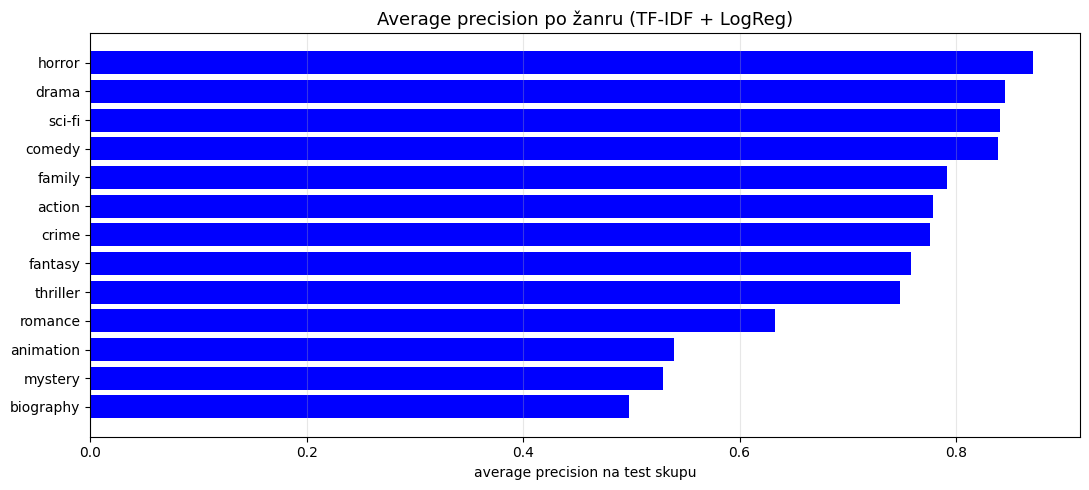

najlošija 3: biography, mystery, animation
najbolja  3: sci-fi, drama, horror


In [17]:
best_model_name = test_results.index[0]
best_va, best_te = ALL_MODELS[best_model_name]
best_thresholds = tune_thresholds(y_val, best_va)
print("najbolji model:", best_model_name)

# AP po zanru -- prosek od 0.73 krije raspon od 0.49 do 0.87
ap = per_genre_ap(y_test, best_te).sort_values()

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(ap.index, ap.values, color="blue")
ax.set_title(f"Average precision po žanru ({best_model_name})", fontsize=13)
ax.set_xlabel("average precision na test skupu")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("najlošija 3:", ", ".join(ap.index[:3]))
print("najbolja  3:", ", ".join(ap.index[-3:]))

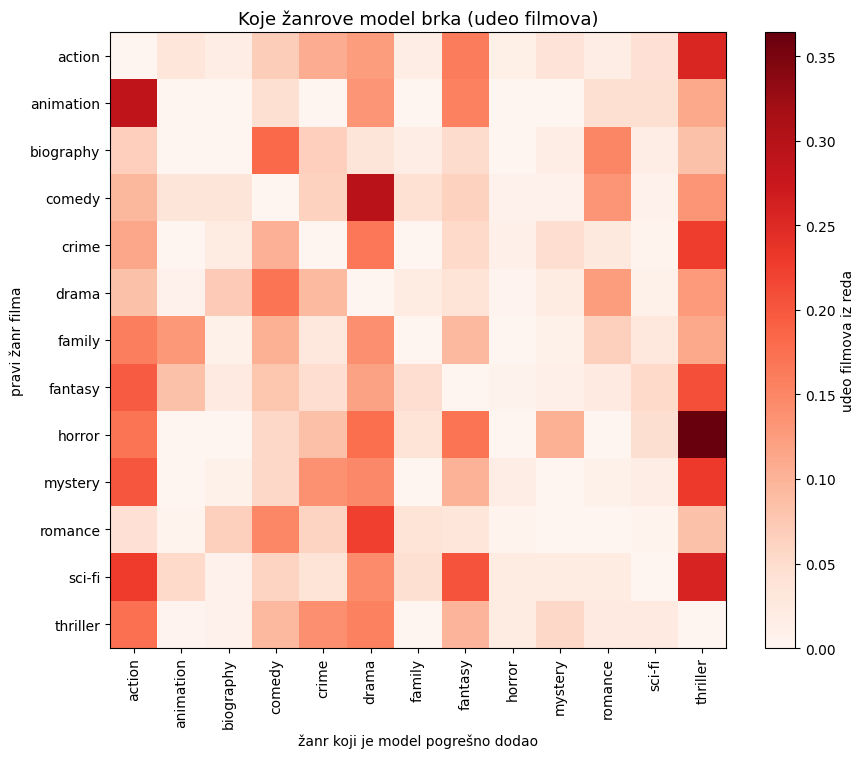

,pravi žanr,pogrešno dodat,udeo filmova
0,horror,thriller,36%
1,comedy,drama,29%
2,animation,action,29%
3,sci-fi,thriller,26%
4,action,thriller,25%
5,mystery,thriller,23%
6,sci-fi,action,23%
7,crime,thriller,23%


In [18]:
# Koje zanrove model brka.
# Vrednost = UDEO filmova iz reda kojima je model pogresno dodao zanr iz kolone.
# Deli se brojem filmova u redu -- bez toga bi cesti zanrovi (drama se predvidi
# 640 puta) svetleli svuda, prosto zato sto se cesto predvidjaju.
predictions = (best_te >= best_thresholds).astype(int)

M = np.zeros((len(GENRES), len(GENRES)))
for i in range(len(GENRES)):
    ima_zanr = y_test[:, i] == 1
    for j in range(len(GENRES)):
        if i != j:
            pogresno = (predictions[ima_zanr, j] == 1) & (y_test[ima_zanr, j] == 0)
            M[i, j] = pogresno.sum() / max(ima_zanr.sum(), 1)

confusion_counts = pd.DataFrame(M, index=GENRES, columns=GENRES)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(confusion_counts, cmap="Reds")
ax.set_xticks(range(len(GENRES))); ax.set_xticklabels(GENRES, rotation=90)
ax.set_yticks(range(len(GENRES))); ax.set_yticklabels(GENRES)
ax.set_xlabel("žanr koji je model pogrešno dodao")
ax.set_ylabel("pravi žanr filma")
ax.set_title("Koje žanrove model brka (udeo filmova)", fontsize=13)
plt.colorbar(im, label="udeo filmova iz reda")
plt.tight_layout()
plt.show()

confused_pairs = confusion_counts.stack().sort_values(ascending=False).head(8).reset_index()
confused_pairs.columns = ["pravi žanr", "pogrešno dodat", "udeo filmova"]
confused_pairs["udeo filmova"] = (confused_pairs["udeo filmova"] * 100).round(0).astype(int).astype(str) + "%"
confused_pairs

## 11. Snimanje

Predikcije su ulaz za fuziju sa modelom za postere. Fuzioni model se trenira na
`val` predikcijama — ne na `train`, jer su tamo bazni modeli prenaučeni.

In [19]:
import joblib

joblib.dump(vectorizer, MODELS / "tfidf_vectorizer.joblib")
joblib.dump(logreg,     MODELS / "text_logreg.joblib")
joblib.dump(minilm,     MODELS / "text_minilm_logreg.joblib")
torch.save(paper_model.state_dict(), MODELS / "text_glove_mlp.pt")

np.savez(MODELS / "text_predictions.npz",
         val_glove=score_glove_va,   test_glove=score_glove_te,
         val_logreg=score_logreg_va, test_logreg=score_logreg_te,
         val_minilm=score_minilm_va, test_minilm=score_minilm_te,
         thresholds=best_thresholds, genres=np.array(GENRES), best_model=best_model_name)

test_results.to_csv(MODELS / "text_results_test.csv")
print(f"snimljeno u {MODELS}")

snimljeno u models/


## 12. Zaključci

### Rezultati na test skupu

| Model | AP_micro | AP_macro | AP_samples |
|---|---|---|---|
| **TF-IDF + LogReg** | 0.7733 | **0.7268** | 0.8430 |
| GloVe + MLP *(replikacija rada)* | 0.6564 | 0.6619 | 0.7614 |
| MiniLM + LogReg | 0.5827 | 0.5714 | 0.7111 |
| *Rad — tekst, objavljeno* | *0.6317* | *0.6195* | *0.7497* |

### 1. Replikacija je uspela

Naša replika daje **0.6619 macro AP** naspram objavljenih **0.6195**. Razlika je
mala i objašnjiva: popravili smo pokvareno UTF-8 kodiranje u trećini sinopsisa i
biramo pragove po žanru. To potvrđuje da lanac obrade radi ispravno, pa je sve
što je iznad te brojke zasluga metode, a ne razlike u podacima.

### 2. TF-IDF nadmašuje pristup iz rada

Uzrok je **način na koji rad sažima tekst**. Sinopsis od oko 600 reči svodi se na
300 brojeva tako što se za svaku poziciju izračuna srednja vrednost GloVe vektora
svih reči. Takav račun sve reči tretira podjednako, pa se gubi redosled reči, a
one retke se izjednače sa najčešćim.

Reč `zombie` javlja se u 36 od 3454 sinopsisa i TF-IDF joj daje težinu 5.54, dok
`the` postoji u svakom tekstu i dobija 1.0 — pet puta manje. U GloVe računu obe
učestvuju istom količinom, pa `the`, koje se u tekstu javi pedesetak puta, ima i
pedeset puta veći uticaj na rezultat od reči koja stvarno odaje žanr.

Izmereno usput: podrazumevana postavka `TfidfVectorizer`-a daje 0.6581. Dodavanjem
bigrama, logaritamskog `tf`, izbacivanja stop-reči i ograničenja rečnika rezultat
raste na 0.7268.

### 3. Transformer je bio najlošiji — i to je koristan nalaz

MiniLM čita najviše **256 tokena**, a **80% sinopsisa je duže od te granice**.
Prvi film ima 1037 tokena, dakle model vidi 25% teksta. Uz to nije dotreniran,
nego korišćen kao zamrznut ekstraktor.

Zaključak nije da transformeri ne valjaju, nego da zamrznut i skraćen transformer
gubi od dobrog TF-IDF-a na dugačkim tekstovima.

### 4. Gde model greši

Najlošiji žanrovi su `biography`, `mystery` i `animation`, najbolji `sci-fi`,
`drama` i `horror`. Razlog je dvojak:

- **retkost** — `animation` ima 175 primera naspram 1806 za `drama`
- **rečnik** — `sci-fi` i `horror` imaju prepoznatljive reči (*spaceship*,
  *vampire*), dok `mystery` nema svoj rečnik jer ga definiše struktura radnje

Kod **4.1% filmova** (41 od 989) nijedan predviđeni žanr nije tačan. Matrica
brkanja pokazuje da model meša žanrove koji se i u stvarnosti preklapaju:
*thriller* sa *crime*, *drama* sa *romance*.

### Ograničenja

- Rad koristi GloVe 42B CommonCrawl, mi 6B Wikipedia+Gigaword zbog veličine.
- Validacioni skup koristimo dvaput — za rani prekid i za izbor pragova.
- U podacima postoji šum: film *Blow Out* (1981) ima sinopsis istoimenog crtanog
  filma iz 1936, jer su sinopsisi skidani sa Wikipedije po naslovu.

### Sledeći korak

Predikcije sva tri modela su u `models/text_predictions.npz`. Spajaju se sa
modelom za postere u svesci o fuziji — i tek tamo ima smisla poređenje sa
kombinovanim modelom iz rada (0.5641 macro AP), jer se tek tada porede iste
stvari: ansambl protiv ansambla.

Poster modeli su u `02_poster_classification.ipynb`, fuzija u `03_fusion.ipynb`.